In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input,Lambda,Dense,Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3,preprocess_input
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from  tensorflow.keras.models import Sequential
import numpy as np
from glob import glob

In [15]:
image_size = [224,224]
train_path = 'train'
test_path = 'valid'

In [16]:
inception = InceptionV3(input_shape=image_size + [3],weights='imagenet',include_top=False)
for layer in inception.layers:
    layer.trainable = False

In [17]:
folder = glob('train/*')
x = Flatten()(inception.output)
prediction = Dense(len(folder),activation='softmax')(x)
models = Model(inputs = inception.input,outputs = prediction)

In [18]:
models.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 111, 111,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 109, 109,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 109, 109,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 54, 54,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 54, 54,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 52, 52,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,314,794 (85.12 MB)

 Trainable params: 512,010 (1.95 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [19]:
models.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [20]:
train_datagen = ImageDataGenerator(rescale=1./255,shear_range=0.2,zoom_range=0.2,horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)
training_set = train_datagen.flow_from_directory('train',target_size = (224,224),batch_size=16,class_mode='categorical')
test_set = train_datagen.flow_from_directory('valid',target_size = (224,224),batch_size=16,class_mode='categorical')


Found 18345 images belonging to 10 classes.
Found 4585 images belonging to 10 classes.


In [21]:
r = models.fit(training_set,validation_data=test_set,epochs=5,steps_per_epoch=len(training_set),validation_steps=len(test_set))

Epoch 1/5
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 5590s 5s/step - accuracy: 0.6814 - loss: 4.1562 - val_accuracy: 0.7771 - val_loss: 3.4375
Epoch 2/5
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 29725s 26s/step - accuracy: 0.7860 - loss: 3.5226 - val_accuracy: 0.7895 - val_loss: 3.8897
Epoch 3/5
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 2919s 3s/step - accuracy: 0.8227 - loss: 3.2748 - val_accuracy: 0.8207 - val_loss: 3.2600
Epoch 4/5
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 2904s 3s/step - accuracy: 0.8390 - loss: 3.1789 - val_accuracy: 0.7769 - val_loss: 4.8123
Epoch 5/5
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 2699s 2s/step - accuracy: 0.8546 - loss: 2.9421 - val_accuracy: 0.8264 - val_loss: 3.8543


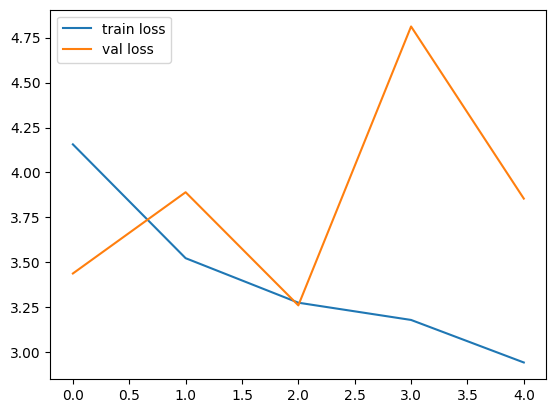

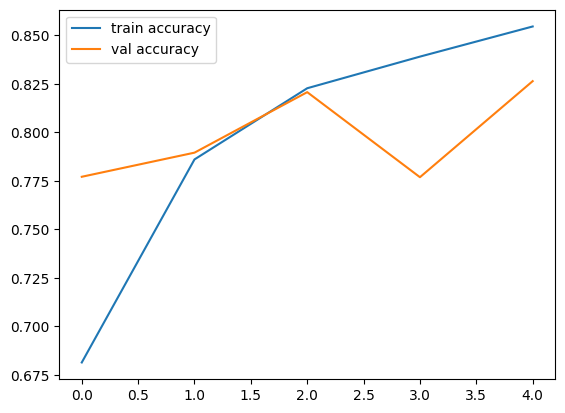

<Figure size 640x480 with 0 Axes>

In [22]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [23]:
models.save('model_inceptionv3.h5')

In [24]:
y_pred = models.predict(test_set)
y_pred

287/287 ━━━━━━━━━━━━━━━━━━━━ 629s 2s/step


array([[0.0000000e+00, 3.9698221e-17, 0.0000000e+00, ..., 1.0741889e-25,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 0.0000000e+00],
       [1.0000000e+00, 1.0284012e-28, 0.0000000e+00, ..., 2.5442571e-19,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [1.6835007e-37, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 5.5150620e-15],
       [0.0000000e+00, 6.5080803e-31, 7.2085926e-14, ..., 0.0000000e+00,
        5.4906720e-17, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [25]:
import numpy as np
y_pred = np.argmax(y_pred,axis=1)
y_pred

array([4, 8, 0, ..., 5, 4, 5], dtype=int64)

In [28]:
from tensorflow.keras.models import load_model
model = load_model('model_inceptionv3.h5')

In [56]:

import numpy as np

# 1. Load image
img = image.load_img('train/Tomato___Bacterial_spot/img1.jpg', target_size=(224,224))

# 2. Convert to array
img = image.img_to_array(img)

# 3. Expand dimension (ONLY ONCE)
img = np.expand_dims(img, axis=0)

# 4. Preprocess
img = preprocess_input(img)



In [57]:
pred = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


In [58]:
a=np.argmax(model.predict(img), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


In [59]:
a==1

array([False])